In [13]:
# --- Import Library ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import joblib

In [14]:
# --- Load Dataset ---
df = pd.read_csv("Online Sales Data.csv")
df['Date'] = pd.to_datetime(df['Date'])

daily_sales = df.groupby('Date').agg({
    'Total Revenue': 'sum',
    'Units Sold': 'sum',
    'Unit Price': 'mean'
}).reset_index()

# Set kolom Date sebagai index agar bisa divisualisasikan dengan mudah
daily_sales.set_index('Date', inplace=True)
daily_sales.head()

,Total Revenue,Units Sold,Unit Price
Date,,,
2024-01-01,1999.98,2,999.99
2024-01-02,499.99,1,499.99
2024-01-03,209.97,3,69.99
2024-01-04,63.96,4,15.99
2024-01-05,89.99,1,89.99


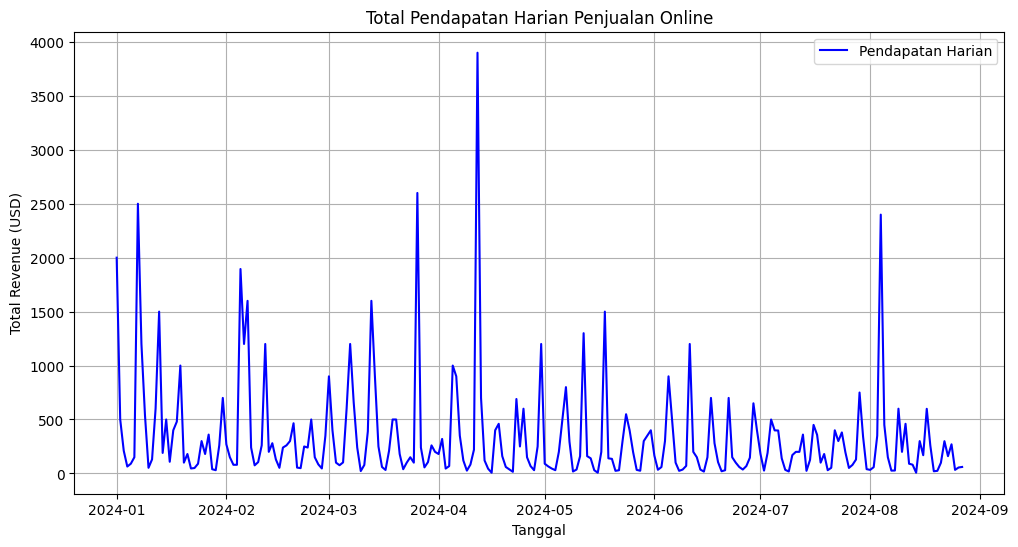

In [15]:
# --- Visualisasi Data ---
# Menampilkan tren pendapatan harian
plt.figure(figsize=(12,6))
plt.plot(daily_sales['Total Revenue'], color='blue', label='Pendapatan Harian')
plt.title('Total Pendapatan Harian Penjualan Online')
plt.xlabel('Tanggal')
plt.ylabel('Total Revenue (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# --- Normalisasi Data ---
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(daily_sales[['Total Revenue', 'Units Sold', 'Unit Price']])

scaled_data.shape

(240, 3)

In [17]:
# --- Windowing Data ---
timesteps = 30
X, y = [], []
for i in range(timesteps, len(scaled_data)):
    X.append(scaled_data[i-timesteps:i])     
    y.append(scaled_data[i, 0])              

X, y = np.array(X), np.array(y)
print("Bentuk X:", X.shape)
print("Bentuk y:", y.shape)

Bentuk X: (210, 30, 3)
Bentuk y: (210,)


In [18]:
# --- Split Data ---
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Data train:", X_train.shape, "Data test:", X_test.shape)

Data train: (168, 30, 3) Data test: (42, 30, 3)


In [19]:
# --- Bangun Model LSTM ---
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)  
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

c:\Users\royba\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 128)        │        67,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,105 (465.25 KB)

 Trainable params: 119,105 (465.25 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# --- Pelatihan Model ---
history = model.fit(X_train, y_train,
                    epochs=40,          
                    batch_size=16,
                    validation_split=0.1,
                    verbose=1)

Epoch 1/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0269 - val_loss: 0.0017
Epoch 2/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0180 - val_loss: 0.0023
Epoch 3/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0151 - val_loss: 0.0019
Epoch 4/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0166 - val_loss: 0.0020
Epoch 5/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0128 - val_loss: 0.0021
Epoch 6/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0127 - val_loss: 0.0024
Epoch 7/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0148 - val_loss: 0.0019
Epoch 8/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0157 - val_loss: 0.0021
Epoch 9/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0180 - val_loss: 0.0019
Epoch 10/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0189 - val_loss: 0.0019
Epoch 11/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0153 - val_loss: 0.0027
Epoch 12/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0

In [21]:
# --- Evaluasi Model ---
predictions = model.predict(X_test)

pred_extended = np.concatenate((predictions, np.zeros((len(predictions), 2))), axis=1)
predictions_inv = scaler.inverse_transform(pred_extended)[:, 0]

y_test_extended = np.concatenate((y_test.reshape(-1,1), np.zeros((len(y_test), 2))), axis=1)
y_test_inv = scaler.inverse_transform(y_test_extended)[:, 0]

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 250ms/step


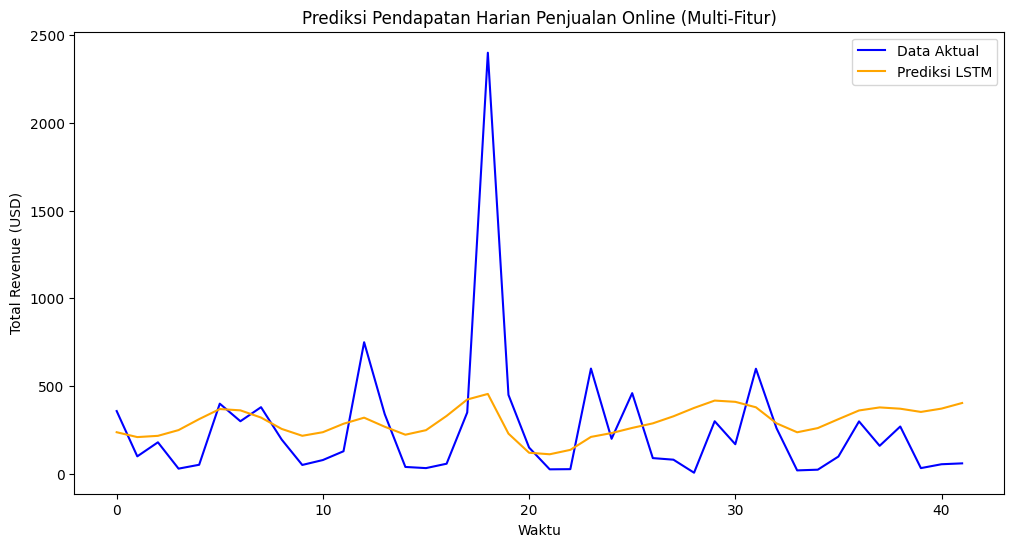

In [22]:
# --- Visualisasi Hasil ---
plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label='Data Aktual', color='blue')
plt.plot(predictions_inv, label='Prediksi LSTM', color='orange')
plt.title('Prediksi Pendapatan Harian Penjualan Online (Multi-Fitur)')
plt.xlabel('Waktu')
plt.ylabel('Total Revenue (USD)')
plt.legend()
plt.show()

In [23]:
# --- Hitung RMSE ---
rmse = np.sqrt(mean_squared_error(y_test_inv, predictions_inv))
print(f"Nilai RMSE: {rmse:.2f}")

Nilai RMSE: 362.21


In [25]:
# --- Simpan Model dan Scaler ---
model.save("model_sales.h5")
joblib.dump(scaler, "scaler_sales.pkl")

['scaler_sales.pkl']